<a href="https://colab.research.google.com/github/MarcGaac/DSC1107/blob/main/LabFA_1_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# ===============================
# Assignment: nycflights13 Analysis
# ===============================

# 1. Install and load required packages
if (!require("nycflights13")) install.packages("nycflights13")
if (!require("tidyverse")) install.packages("tidyverse")
library(nycflights13)
library(tidyverse)

# Load the flights dataset
data("flights")

# ============================================================
# Part A. Data Understanding & Preparation
# ============================================================

# ---- A1. Dataset Overview ----
cat("=== A1. Dataset Overview ===\n")
str(flights)        # Structure: variable types and first few values
cat("\nDimensions:\n")
dim(flights)        # 336,776 rows, 19 columns
cat("\nVariable types:\n")
glimpse(flights)    # Compact summary with types

# Identify variable types:
# - Numeric: dep_time, sched_dep_time, dep_delay, arr_time, sched_arr_time,
#            arr_delay, flight, air_time, distance, hour, minute
# - Categorical (character/factor): year, month, day, carrier, tailnum, origin,
#            dest, time_hour (POSIXct)

# ---- A2. Data Cleaning ----
cat("\n=== A2. Data Cleaning ===\n")
# Missing values in dep_delay and arr_delay
missing_dep <- sum(is.na(flights$dep_delay))
missing_arr <- sum(is.na(flights$arr_delay))
cat("Missing dep_delay:", missing_dep, "\n")
cat("Missing arr_delay:", missing_arr, "\n")

# Remove rows with missing departure or arrival delays
flights_clean <- flights %>%
  filter(!is.na(dep_delay) & !is.na(arr_delay))

cat("Original rows:", nrow(flights), "\n")
cat("Cleaned rows:", nrow(flights_clean), "\n")
cat("Removed rows:", nrow(flights) - nrow(flights_clean), "\n")


# ============================================================
# Part C. Interpretation & Insights
# ============================================================

# ---- C1. Summary Statistics ----
cat("\n=== C1. Summary Statistics ===\n")
mean_dep <- mean(flights_clean$dep_delay, na.rm = TRUE)
median_dep <- median(flights_clean$dep_delay, na.rm = TRUE)
mean_arr <- mean(flights_clean$arr_delay, na.rm = TRUE)
median_arr <- median(flights_clean$arr_delay, na.rm = TRUE)

cat("Departure Delay - Mean:", round(mean_dep, 2), "minutes\n")
cat("Departure Delay - Median:", round(median_dep, 2), "minutes\n")
cat("Arrival Delay   - Mean:", round(mean_arr, 2), "minutes\n")
cat("Arrival Delay   - Median:", round(median_arr, 2), "minutes\n")



=== A1. Dataset Overview ===
tibble [336,776 × 19] (S3: tbl_df/tbl/data.frame)
 $ year          : int [1:336776] 2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month         : int [1:336776] 1 1 1 1 1 1 1 1 1 1 ...
 $ day           : int [1:336776] 1 1 1 1 1 1 1 1 1 1 ...
 $ dep_time      : int [1:336776] 517 533 542 544 554 554 555 557 557 558 ...
 $ sched_dep_time: int [1:336776] 515 529 540 545 600 558 600 600 600 600 ...
 $ dep_delay     : num [1:336776] 2 4 2 -1 -6 -4 -5 -3 -3 -2 ...
 $ arr_time      : int [1:336776] 830 850 923 1004 812 740 913 709 838 753 ...
 $ sched_arr_time: int [1:336776] 819 830 850 1022 837 728 854 723 846 745 ...
 $ arr_delay     : num [1:336776] 11 20 33 -18 -25 12 19 -14 -8 8 ...
 $ carrier       : chr [1:336776] "UA" "UA" "AA" "B6" ...
 $ flight        : int [1:336776] 1545 1714 1141 725 461 1696 507 5708 79 301 ...
 $ tailnum       : chr [1:336776] "N14228" "N24211" "N619AA" "N804JB" ...
 $ origin        : chr [1:336776] "EWR" "LGA" "JFK" "J

[1] 336776     19


Variable types:
Rows: 336,776
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ sched_dep_time <int> 515, 529, 540, 545, 600, 558, 600, 600, 600, 600, 600, …
$ dep_delay      <dbl> 2, 4, 2, -1, -6, -4, -5, -3, -3, -2, -2, -2, -2, -2, -1…
$ arr_time       <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…
$ sched_arr_time <int> 819, 830, 850, 1022, 837, 728, 854, 723, 846, 745, 851,…
$ arr_delay      <dbl> 11, 20, 33, -18, -25, 12, 19, -14, -8, 8, -2, -3, 7, -1…
$ carrier        <chr> "UA", "UA", "AA", "B6", "DL", "UA", "B6", "EV", "B6", "…
$ flight         <int> 1545, 1714, 1141, 725, 461, 1696, 507, 5708, 79, 301, 4…
$ tailnum        <chr> "N14228", "N24211", "N619AA", "N804JB", "N668DN", "N39


=== B1. Histogram of Departure Delays ===


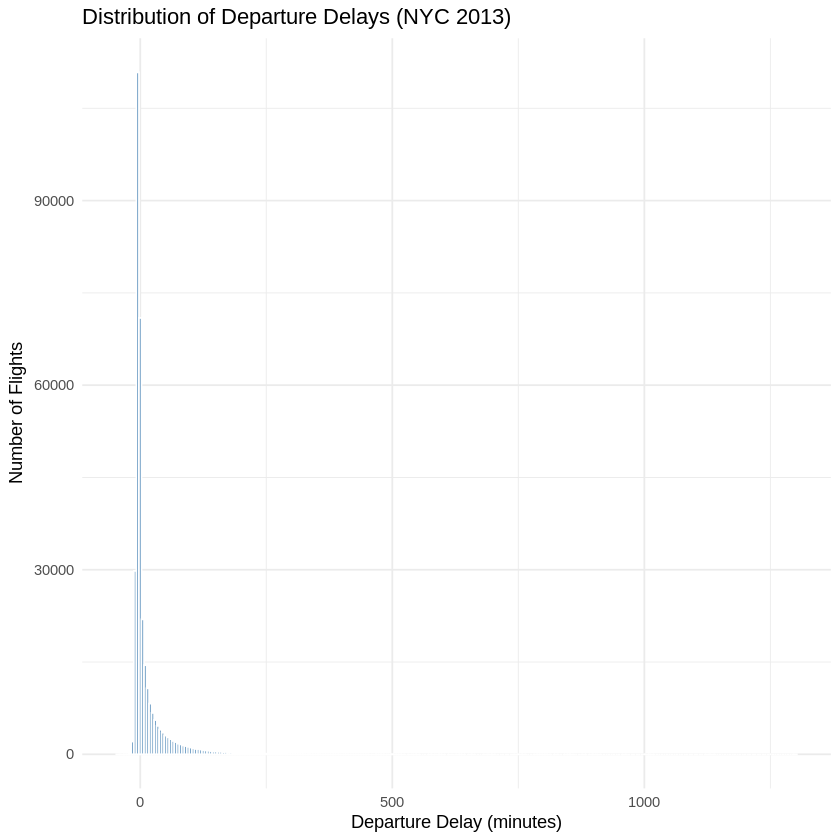

In [13]:
# ============================================================
# Part B. Data Visualization (using cleaned data)
# ============================================================

# ---- B1. Histogram of Departure Delays ----
cat("\n=== B1. Histogram of Departure Delays ===\n")
p1 <- ggplot(flights_clean, aes(x = dep_delay)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Departure Delays (NYC 2013)",
    x = "Departure Delay (minutes)",
    y = "Number of Flights"
  ) +
  theme_minimal()
print(p1)


=== B2. Boxplot of Departure Delay by Airline ===


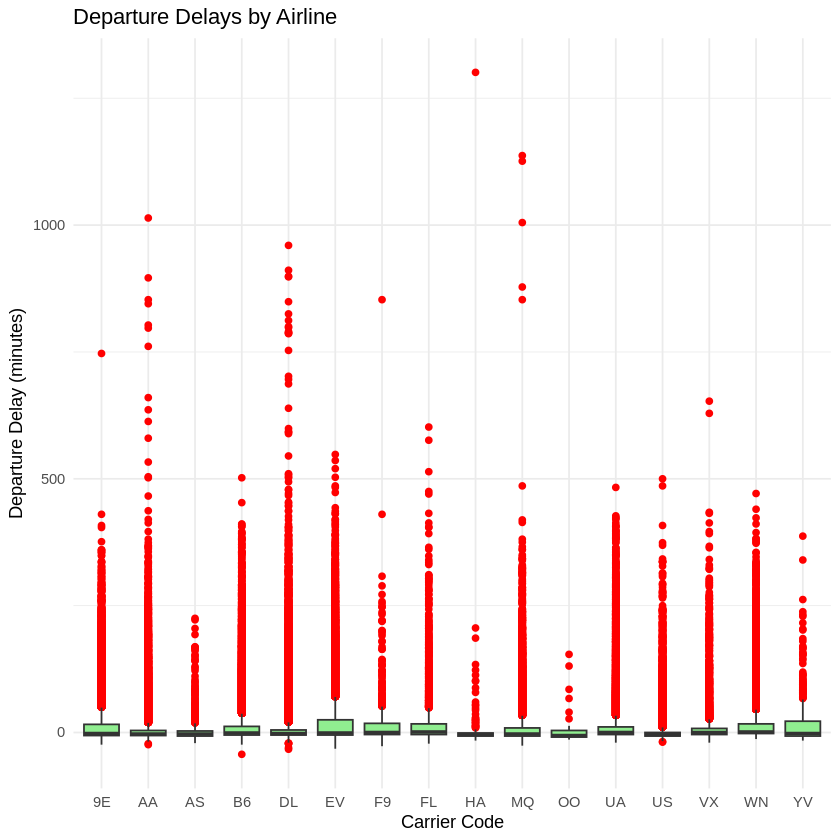

In [14]:
# ---- B2. Boxplot by Airline ----
cat("\n=== B2. Boxplot of Departure Delay by Airline ===\n")
p2 <- ggplot(flights_clean, aes(x = carrier, y = dep_delay)) +
  geom_boxplot(fill = "lightgreen", outlier.color = "red") +
  labs(
    title = "Departure Delays by Airline",
    x = "Carrier Code",
    y = "Departure Delay (minutes)"
  ) +
  theme_minimal()
print(p2)

The airline EV (ExpressJet) and MQ (Envoy) show the greatest variability with many outliers.

EV has the highest median delay and the widest interquartile range, indicating it is the most inconsistent.


=== B3. Distance vs Arrival Delay ===


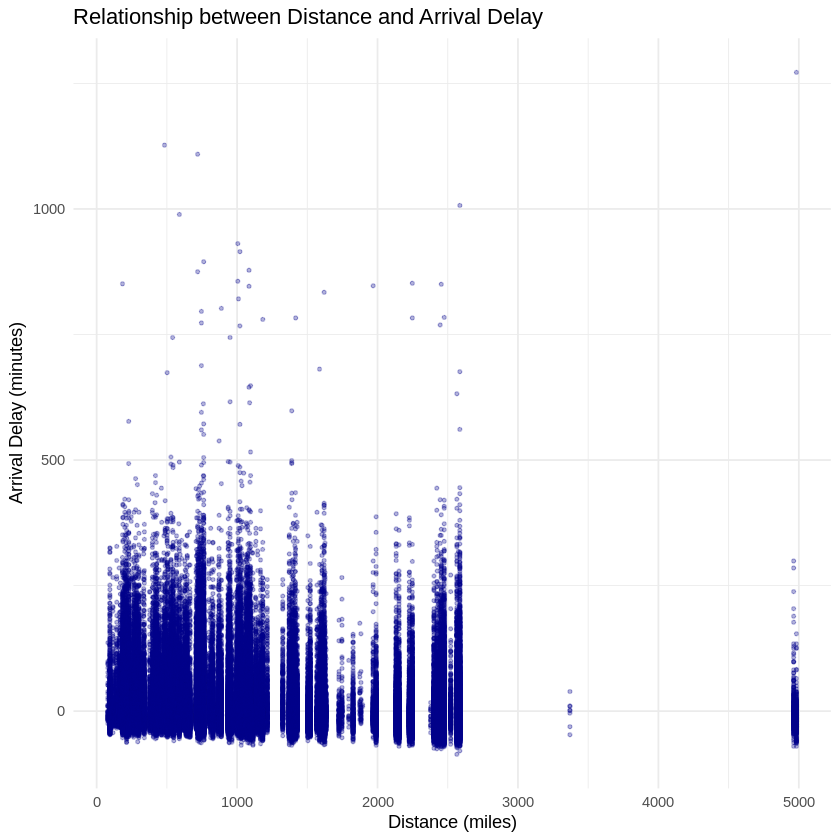

In [15]:
# ---- B3. Scatter Plot: Distance vs Arrival Delay ----
cat("\n=== B3. Distance vs Arrival Delay ===\n")
p3 <- ggplot(flights_clean, aes(x = distance, y = arr_delay)) +
  geom_point(alpha = 0.3, size = 0.8, color = "darkblue") +
  labs(
    title = "Relationship between Distance and Arrival Delay",
    x = "Distance (miles)",
    y = "Arrival Delay (minutes)"
  ) +
  theme_minimal()
print(p3)

C2

Based on the analysis, the main factor associated with delays appears to be the airline (carrier), as shown by the boxplot (B2) where carriers like EV exhibit both higher median delays and wider spread. Additionally, the histogram (B1) shows that most delays are short, but a minority of flights experience very long delays. The scatter plot (B3) suggests that distance is not a strong predictor of arrival delay – flights of all distances can be delayed. However, early‑morning or late‑night flights (not shown here) might show different patterns. Overall, operational differences between airlines and congestion likely contribute more than flight distance.